



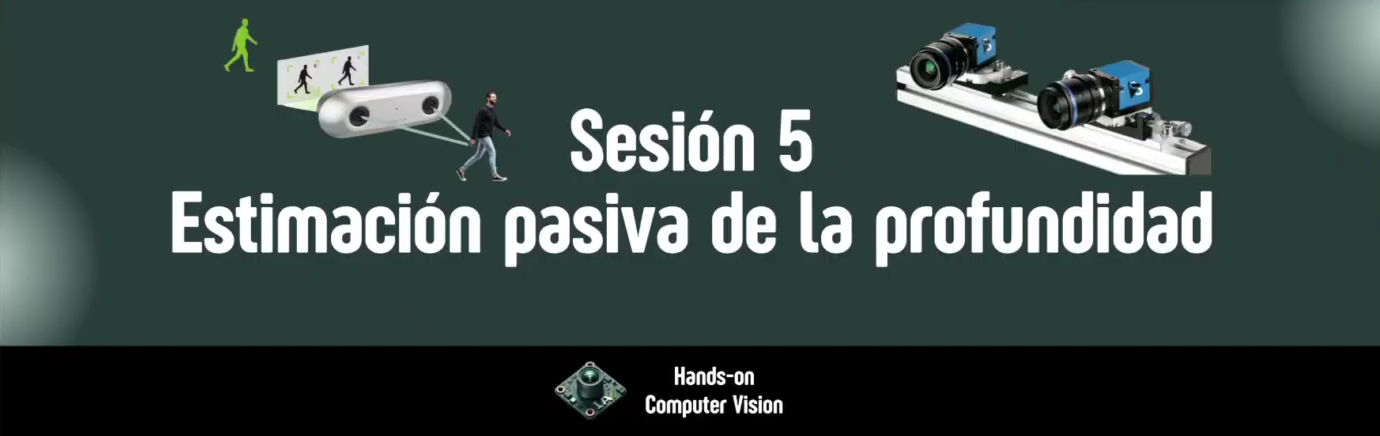




[feedback] la descripción es noise. en este notebook no estamos calculando la disparidad. solamente depth con modelos fundacionales.

# <center> **04. Estimación pasiva de la profundidad** </center>

La estimación pasiva de la profundidad es el conjunto de técnicas y algoritmos para estimar la distancia observada de objetos para permitir una comprensión tridimensional (3D) del entorno circundante. Durante esta sesión vamos a aplicar los conceptos explicados, **para estimar la disparidad en imágenes estéreo prediseñadas mediante diversas técnicas de programación y así obtener los mapas de disparidad y profundidad.**

In [ ]:
# @title **Instalamos Paquetes necesarios**
!pip install --upgrade timm -q

import os
import cv2
import torch
import pandas
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
from transformers import (
    AutoImageProcessor,
    AutoModelForDepthEstimation,
    ZoeDepthForDepthEstimation,
)


def resolver_ruta_sesion5(*partes, debe_existir=True):
    cwd = Path.cwd().resolve()
    for base in (cwd, *cwd.parents):
        for raiz in (base, base / "sesiones" / "sesion5"):
            ruta = raiz.joinpath(*partes)
            if ruta.exists():
                return ruta
    if debe_existir:
        raise FileNotFoundError(f"No se encontró el archivo: {'/'.join(partes)}")
    return Path.cwd().joinpath(*partes)


# Descargar imágenes si no existen en la carpeta desde la que se ejecuta el notebook.
archivos = {
    "28.png": "https://raw.githubusercontent.com/semilleroCV/Hands-on-Computer-Vision/f0142bf70526f90218f13836038e94cca4d94e7d/sesiones/sesion5/28.png",
    "color.png": "https://raw.githubusercontent.com/semilleroCV/Hands-on-Computer-Vision/f0142bf70526f90218f13836038e94cca4d94e7d/sesiones/sesion5/color.png",
}

for nombre, url in archivos.items():
    if not resolver_ruta_sesion5(nombre, debe_existir=False).exists():
        destino = Path.cwd() / nombre
        !wget -O {str(destino)} {url}


In [ ]:
# @title prerequisitos

def plot_depth(depth, title=None):
    fig, ax = plt.subplots(figsize=(8, 6))
    img = ax.imshow(np.array(depth), cmap="inferno")
    ax.axis("off")
    if title:
        ax.set_title(title)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    plt.colorbar(img, cax=cax).set_label("Depth")
    plt.tight_layout()
    plt.show()


def normalize_depth(depth):
    depth_np = np.array(depth)
    depth_min, depth_max = depth_np.min(), depth_np.max()
    if depth_max - depth_min == 0:
        return np.zeros_like(depth_np)
    return (depth_np - depth_min) / (depth_max - depth_min)


def get_line(predicted_image, true_depth_image):
    x = predicted_image.flatten()
    y = true_depth_image.flatten()

    # Filtrar valores válidos (ni NaN ni Inf)
    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2:
        return None, None, None, None  # No hay suficientes puntos válidos

    try:
        a, b = np.polyfit(x, y, 1)
        return a, b, x, y
    except Exception as e:
        print(f"Error al ajustar línea: {e}")
        return None, None, None, None


def compute_scale_and_shift(prediction, target):
    """
    Compute scale and shift to align the 'prediction' to the 'target' using the 'mask'.

    This function solves the system Ax = b to find the scale (x_0) and shift (x_1) that aligns the prediction to the target.
    The system matrix A and the right hand side b are computed from the prediction, target, and mask.

    Args:
        prediction (torch.Tensor): Predicted values.
        target (torch.Tensor): Ground truth values.
        mask (torch.Tensor): Mask that indicates the zones to evaluate.

    Returns:
        tuple: Tuple containing the following:
            x_0 (torch.Tensor): Scale factor to align the prediction to the target.
            x_1 (torch.Tensor): Shift to align the prediction to the target.
    """
    # system matrix: A = [[a_00, a_01], [a_10, a_11]]
    a_00 = torch.sum(prediction * prediction, (1, 2))
    a_01 = torch.sum(prediction, (1, 2))
    a_11 = torch.sum(torch.ones_like(prediction), (1, 2))

    # right hand side: b = [b_0, b_1]
    b_0 = torch.sum(prediction * target, (1, 2))
    b_1 = torch.sum(target, (1, 2))

    # solution: x = A^-1 . b = [[a_11, -a_01], [-a_10, a_00]] / (a_00 * a_11 - a_01 * a_10) . b
    x_0 = torch.zeros_like(b_0)
    x_1 = torch.zeros_like(b_1)

    det = a_00 * a_11 - a_01 * a_01
    # A needs to be a positive definite matrix.
    valid = det > 0

    x_0[valid] = (a_11[valid] * b_0[valid] - a_01[valid] * b_1[valid]) / det[valid]
    x_1[valid] = (-a_01[valid] * b_0[valid] + a_00[valid] * b_1[valid]) / det[valid]

    return x_0, x_1


def compute_scale_and_shift_numpy(prediction, target):
    pred = torch.from_numpy(prediction).unsqueeze(0)
    tgt = torch.from_numpy(target).unsqueeze(0)

    x_0, x_1 = compute_scale_and_shift(pred, tgt)
    aligned = x_0[0].item() * pred[0] + x_1[0].item()

    return aligned.numpy()


## <font color='#4C5FDA'>**1. Estimación monocular de la profundidad**</font> <a name="tema1">




### <font color="EB9A54"> **1.1:** </font> Probemos modelos fundacionales de estimación monocular

## **Inferencia**

In [ ]:
# @title **Cargamos la imagen RGB y la profundidad**
# Ruta de la imagen
rgb = resolver_ruta_sesion5("color.png")

# Carga la imagen
image = Image.open(rgb).convert("RGB")

# Cargamos el gt
depth = resolver_ruta_sesion5("28.png")
# Carga la imagen
depth_image = Image.open(depth)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image)
ax[0].set_title("Imagen RGB")
ax[0].axis("off")
ax[1].imshow(depth_image, cmap="inferno")
ax[1].set_title("Imagen de profundidad")
ax[1].axis("off")
plt.show()


# Modelos de predicción de profundidad

In [ ]:
# [feedback] esto de acá requiere un token de hugging face. remover el noise
#  de que al ejecutar la celda lo pida

# @title **ZeoDepth**
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

image_processor = AutoImageProcessor.from_pretrained("Intel/zoedepth-nyu-kitti")
model = ZoeDepthForDepthEstimation.from_pretrained("Intel/zoedepth-nyu-kitti")

inputs = image_processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

post_processed_output = image_processor.post_process_depth_estimation(
    outputs,
    source_sizes=[(image.height, image.width)],
)

predicted_depth_zoedepth = post_processed_output[0]["predicted_depth"]

plot_depth(predicted_depth_zoedepth)

In [ ]:
# @title **MiDaS**
model_type = "DPT_Hybrid"

midas = torch.hub.load("intel-isl/MiDaS", model_type)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
midas.to(device)
midas.eval()

midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")

if model_type == "DPT_Large" or model_type == "DPT_Hybrid":
    transform = midas_transforms.dpt_transform
else:
    transform = midas_transforms.small_transform

img = cv2.imread(rgb)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

input_batch = transform(img).to(device)

with torch.no_grad():
    depth_midas = midas(input_batch)

    depth_midas = torch.nn.functional.interpolate(
        depth_midas.unsqueeze(1),
        size=img.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

depth_midas = depth_midas.cpu().numpy()
plot_depth(depth_midas)

In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

image_processor = AutoImageProcessor.from_pretrained(
    "LiheYoung/depth-anything-small-hf"
)
model = AutoModelForDepthEstimation.from_pretrained("LiheYoung/depth-anything-small-hf")

inputs = image_processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

post_processed_output = image_processor.post_process_depth_estimation(
    outputs,
    target_sizes=[(image.height, image.width)],
)

predicted_depth_da1 = post_processed_output[0]["predicted_depth"]

plot_depth(predicted_depth_da1)


In [ ]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

image_processor = AutoImageProcessor.from_pretrained(
    "depth-anything/Depth-Anything-V2-Small-hf"
)
model = AutoModelForDepthEstimation.from_pretrained(
    "depth-anything/Depth-Anything-V2-Small-hf"
)

inputs = image_processor(images=image, return_tensors="pt")

with torch.no_grad():
    outputs = model(**inputs)

post_processed_output = image_processor.post_process_depth_estimation(
    outputs,
    target_sizes=[(image.height, image.width)],
)

predicted_depth_da2 = post_processed_output[0]["predicted_depth"]

plot_depth(predicted_depth_da2)


In [ ]:
# [feedback] las celdas anteriores son innecesarias. considero solamente mostrar
#  la comparativa directa, incluso así, no me parece interactivo, algo más cool
#  sería que los chicos tomen una foto y hagan inferencia en hugging face sin
#  tener una cuenta

# Cargar y procesar ground truth
true_depth = 1.0 / (
    cv2.imread(str(resolver_ruta_sesion5("28.png")), cv2.IMREAD_UNCHANGED).astype(np.float32) + 1e-6
)


# Función para redimensionar mapas de profundidad
def resize(d):
    return cv2.resize(
        np.array(d),
        (true_depth.shape[1], true_depth.shape[0]),
        interpolation=cv2.INTER_CUBIC,
    )


# Redimensionar mapas
depth_maps = [
    resize(predicted_depth_da2),
    resize(depth_midas),
    1.0 / resize(predicted_depth_zoedepth),
    true_depth,
]
titles = ["DepthAnything V2", "MiDaS", "ZoeDepth (inverso)", "Ground Truth (inverso)"]

# Graficar
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
for ax, title, depth in zip(axes.flat, titles, depth_maps):
    im = ax.imshow(depth, cmap="magma")
    make_axes_locatable(ax).append_axes("right", size="5%", pad=0.1).figure.colorbar(
        im, cax=plt.gca()
    )
    ax.set_title(title)
    ax.axis("off")

plt.suptitle("Comparación visual de mapas de profundidad (sin normalizar)", fontsize=16)
plt.tight_layout()
plt.show()


In [ ]:
# Redimensionar y normalizar predicciones
depth_dav1_resized = normalize_depth(resize(predicted_depth_da1))
depth_dav2_resized = normalize_depth(resize(predicted_depth_da2))
depth_midas_resized = normalize_depth(resize(depth_midas))
depth_zoe_resized = normalize_depth(1.0 / resize(predicted_depth_zoedepth))
true_depth_norm = normalize_depth(true_depth)

# Preparar plots
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
titles = ["DepthAnything V1", "DepthAnything V2", "MiDaS", "ZoeDepth"]
depth_maps = [
    depth_dav1_resized,
    depth_dav2_resized,
    depth_midas_resized,
    depth_zoe_resized,
]

for ax, title, depth_map in zip(axes.flat, titles, depth_maps):
    im = ax.imshow(depth_map, cmap="magma")
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, cax=cax, fraction=0.046, pad=0.04)

# Ocultar subplots sobrantes
for ax in axes.flat[len(titles) :]:
    ax.axis("off")

plt.suptitle(
    "Comparación visual de mapas de profundidad normalizados (0 a 1)", fontsize=16
)
plt.tight_layout()
plt.show()


In [ ]:
# [feedback] esto no lo entiendo. sugiero remover

import numpy as np
import matplotlib.pyplot as plt


# Listas de mapas y etiquetas
depth_maps = [
    depth_dav1_resized,
    depth_dav2_resized,
    depth_midas_resized,
    depth_zoe_resized,
]

labels = ["DAV1", "DAV2", "MiDaS", "Zoe"]

true_depth = true_depth_norm

# Crear figura
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, (depth, label) in enumerate(zip(depth_maps, labels)):
    a, b, x, y = get_line(depth, true_depth)

    if a is None:
        axes[i].set_title(f"{label} (ajuste fallido)")
        continue

    axes[i].scatter(x, y, alpha=0.1, s=0.5, label="Datos")
    x_line = np.linspace(0, 1, 100)
    y_line = a * x_line + b
    axes[i].plot(x_line, y_line, color="red", label=f"y = {a:.2f}x + {b:.2f}")
    axes[i].set_title(f"Ajuste {label}")
    axes[i].set_xlabel("Predicción")
    axes[i].set_ylabel("Verdadero")
    axes[i].legend()

plt.tight_layout()
plt.show()


[feedback] este notebook está pobre. sugiero dejar el primero solamente con la parte tradicional, trayendonos a RAFT-Stereo al inicio de aquí.

luego hacer el mismo procedimiento tradicional pero esta vez con un modelo del estado del arte para cada tarea. 
1. disparity -> depth -> reconstruction (raft-stereo o alguno más actual estrictamente reproducible en colab)
2. depth -> reconstruction (unik3d)
3. reconstruction (vggt)
4. comparación de las reconstrucciones (es posible un plot con tres columnas? o hacer un gif con tres columnas comparando la reconstruccion de cada metodo?)

lo más importante es que sea interactivo, que los chicos incluso puedan tomar sus propias fotos y hacer el hands-on real.